In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset("iris")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
X = df[['sepal_length','petal_length']]
y = df[['species']]

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## 🌳 Decision Tree Classifier Parameters

### **criterion** `{“gini”, “entropy”, “log_loss”}` *(default = “gini”)*

Defines the function used to measure the quality of a split:

* **gini** → Gini impurity
* **entropy / log_loss** → Shannon information gain

---

### **splitter** `{“best”, “random”}` *(default = “best”)*

Determines the strategy used to choose splits:

* **best** → Selects the optimal split
* **random** → Selects the best random split

---

### **max_depth** `int` *(default = None)*

Maximum depth of the tree:

* If **None**, nodes expand until:

  * All leaves are pure, or
  * Leaves contain fewer than `min_samples_split` samples

---

### **min_samples_split** `int or float` *(default = 2)*

Minimum samples required to split a node:

* **int** → Minimum number of samples
* **float** → Fraction of total samples
  → `ceil(min_samples_split × n_samples)`

---

### **min_samples_leaf** `int or float` *(default = 1)*

Minimum samples required at a leaf node:

* Ensures each split leaves enough samples in both branches
* Helps **smooth the model** (especially in regression)

Options:

* **int** → Minimum number
* **float** → Fraction of total samples

---

### **min_weight_fraction_leaf** `float` *(default = 0.0)*

Minimum weighted fraction of total sample weights required at a leaf node.

---

### **max_features** `int, float, {“sqrt”, “log2”}` *(default = None)*

Number of features considered when splitting:

* **int** → Fixed number of features
* **float** → Fraction of features
* **sqrt** → √(total features)
* **log2** → log₂(total features)
* **None** → Use all features

---

### **random_state** `int or RandomState` *(default = None)*

Controls randomness:

* Ensures reproducibility when set to a fixed integer
* Randomness occurs in feature selection and tie-breaking

---

### **max_leaf_nodes** `int` *(default = None)*

Limits the number of leaf nodes:

* Tree grows using **best-first strategy**
* If **None**, unlimited leaf nodes

---

### **min_impurity_decrease** `float` *(default = 0.0)*

A split occurs only if impurity decreases by at least this value.

**Weighted impurity decrease:**

```
(N_t / N) * (impurity 
             - (N_t_R / N_t * right_impurity)
             - (N_t_L / N_t * left_impurity))
```

Where:

* `N` = total samples
* `N_t` = samples at current node
* `N_t_L`, `N_t_R` = samples in left & right child

---

### **class_weight** `dict, list of dict, or “balanced”` *(default = None)*

Assigns weights to classes:

* **None** → Equal weights
* **dict** → Custom weights `{class_label: weight}`
* **balanced** → Automatically adjusts:

  ```
  n_samples / (n_classes × np.bincount(y))
  ```

For multi-output:

* Provide a list of dictionaries (one per output column)

---

### **ccp_alpha** `float ≥ 0` *(default = 0.0)*

Controls **cost-complexity pruning**:

* Higher values → More pruning
* Default → No pruning

---

### **monotonic_cst** `array-like` *(default = None)*

Applies monotonic constraints per feature:

* `1` → Increasing relationship
* `0` → No constraint
* `-1` → Decreasing relationship

⚠️ Not supported for:

* Multiclass classification
* Multi-output classification
* Data with missing values

---




In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
accuracy_score(y_test, y_pred)

0.9666666666666667

In [6]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,scoring='accuracy',cv=5))

np.float64(0.9333333333333332)

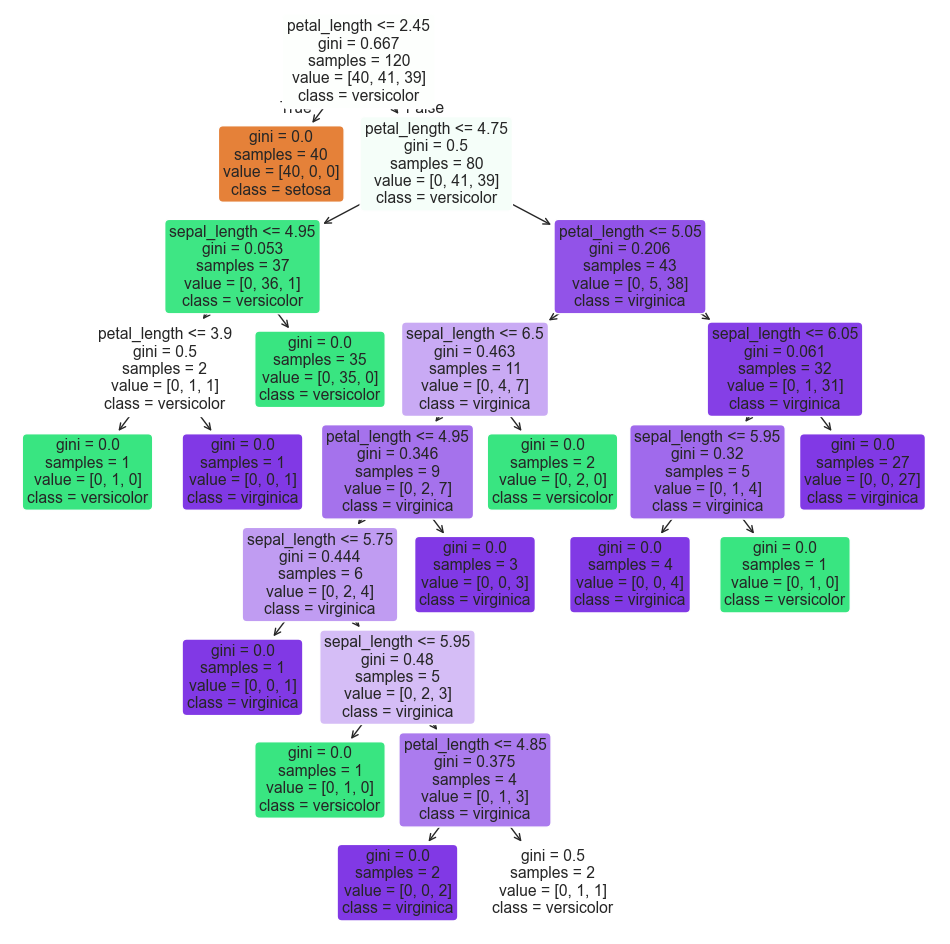

In [7]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,12))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=dt.classes_, rounded=True)
plt.show()

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score

def multiClassMetrices(classifier):
    classifier.fit(X_train,y_train)
    y_pred = classifier.predict(X_test)
    print("Accuracy: ",accuracy_score(y_test, y_pred))
    
    print("--------------------Precision---------------- ")
    print("Precision: ", precision_score(y_test, y_pred,zero_division=0, average=None))
    print("Precision Macro: ", precision_score(y_test, y_pred,zero_division=0, average='macro'))
    print("Precision Weighted:", precision_score(y_test, y_pred,zero_division=0, average='weighted') , "\n\n\n")
    
    print("--------------------Recall---------------- ")
    print("Recall: ", recall_score(y_test, y_pred,zero_division=0, average=None))
    print("Recall Macro: ", recall_score(y_test, y_pred,zero_division=0, average='macro'))
    print("Recall Weighted:", recall_score(y_test, y_pred,zero_division=0, average='weighted'), "\n\n\n")
    
        
    print("--------------------F1 Score---------------- ")
    print("F1 Score: ", f1_score(y_test, y_pred,zero_division=0, average=None))
    print("F1 Score Macro: ", f1_score(y_test, y_pred,zero_division=0, average='macro'))
    print("F1 Score Weighted:", f1_score(y_test, y_pred,zero_division=0, average='weighted') , "\n\n\n")
    
    print("Confusion Matrix: ")
    
    plt.figure(figsize=(12,12))
    labels = np.unique(y_test)
    sns.heatmap(confusion_matrix(y_test, y_pred, labels=labels), annot=True, cmap='Blues', fmt='d', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
    

Accuracy:  0.9666666666666667
--------------------Precision---------------- 
Precision:  [1.  0.9 1. ]
Precision Macro:  0.9666666666666667
Precision Weighted: 0.9700000000000001 



--------------------Recall---------------- 
Recall:  [1.         1.         0.90909091]
Recall Macro:  0.9696969696969697
Recall Weighted: 0.9666666666666667 



--------------------F1 Score---------------- 
F1 Score:  [1.         0.94736842 0.95238095]
F1 Score Macro:  0.9665831244778612
F1 Score Weighted: 0.966750208855472 



Confusion Matrix: 


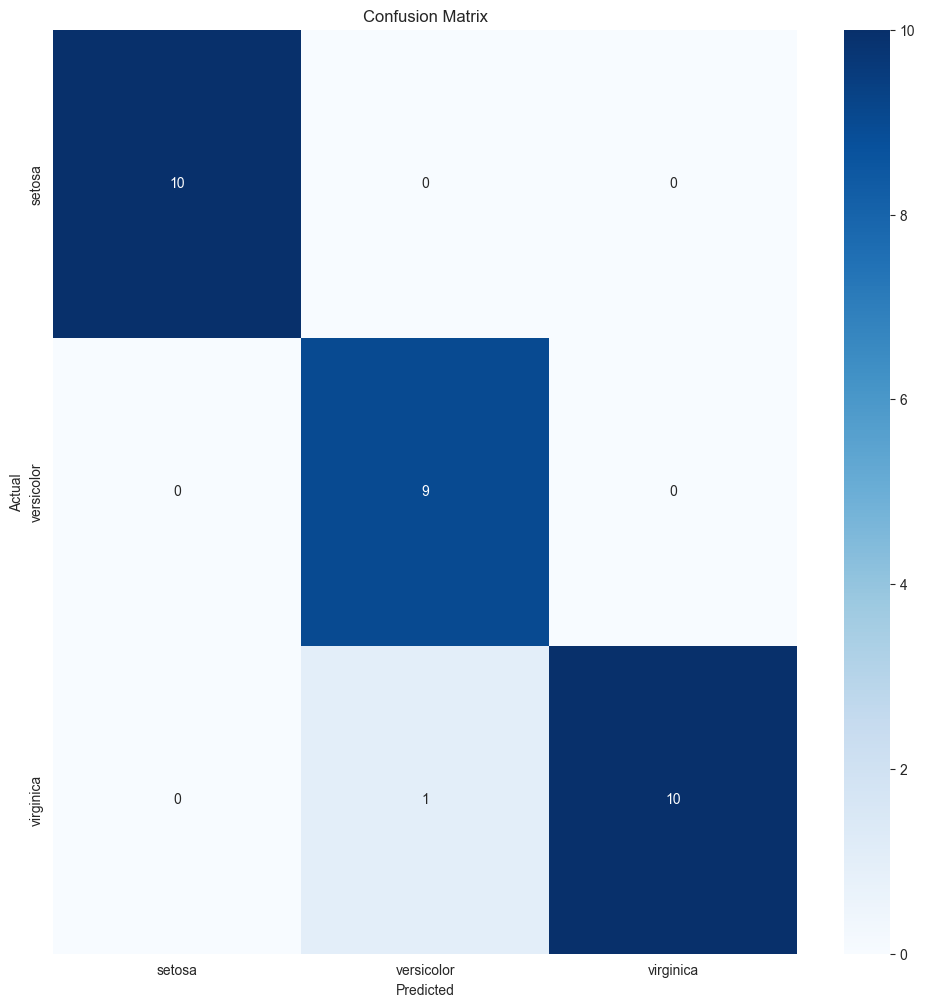

In [10]:
multiClassMetrices(DecisionTreeClassifier())